# Análisis Geoespacial IPM - Zona de Intervención: Barrio Obrero

Este notebook prioriza la visualización cartográfica de las 5 variables más relevantes del Índice de Pobreza Multidimensional (IPM) en el polígono de Barrio Obrero.

### Contexto y Cifras Generales (Corte Mayo 2026)

Para la interpretación de los resultados, se deben considerar dos lógicas opuestas:
1. **Índice de Condición Social (ICS):** Es un indicador directo; un valor del **100% representa el escenario óptimo** (bienestar y acceso pleno).
2. **Índice de Pobreza Multidimensional (IPM):** Es un indicador inverso; un valor del **100% representa el escenario crítico** (pobreza absoluta).

A nivel distrital, Cali presenta una marcada brecha territorial. La **severidad de la pobreza (IPM promedio en manzanas con incidencia > 0)** es del **15.28% en el área urbana**, mientras que en el **área rural se dispara al 38.33%**, impulsada principalmente por carencias en infraestructura básica en los corregimientos.

Este análisis se enfoca en Barrio Obrero para identificar las privaciones específicas que afectan a este territorio de intervención.

In [1]:
# 1. Instalación de dependencias (solo en Colab)
import sys
if 'google.colab' in sys.modules:
    !pip install geopandas matplotlib seaborn openpyxl -q

In [2]:
# 2. Importar librerías
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patheffects import withStroke
import matplotlib.patches as mpatches

sns.set_style('white')
print('Librerías listas')

Librerías listas


In [3]:
# 3. Definir rutas con detección de entorno
REPO_URL = 'https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social.git'
REPO_DIR = 'Pobreza_multidimensional_y_condicion_social'

if 'google.colab' in sys.modules:
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
    else:
        !cd {REPO_DIR} && git pull
    BASE_DIR = REPO_DIR
else:
    if os.path.exists('indice_Pobreza'): BASE_DIR = '.'
    elif os.path.exists('../indice_Pobreza'): BASE_DIR = '..'
    elif os.path.exists('../../indice_Pobreza'): BASE_DIR = '../..'
    else: BASE_DIR = '.'

DATA_BASE = os.path.join(BASE_DIR, 'indice_Pobreza/data')

# Capas
PATH_IPM_VARS_FULL = os.path.join(DATA_BASE, 'geojson_ipm/Mzn_ipm_variables.geojson')
PATH_MANZANAS_FONDO = os.path.join(DATA_BASE, 'geojson_Manzanas_catastrales/geojson_Manzanas_catastrales.geojson')
PATH_AREA_ESTUDIO = os.path.join(DATA_BASE, 'geojson_poligonos_territorio_ITT/poligono_Barrio_Obrero.geojson')

# Cargar datos
gdf_full = gpd.read_file(PATH_IPM_VARS_FULL)
gdf_fondo = gpd.read_file(PATH_MANZANAS_FONDO)
gdf_area = gpd.read_file(PATH_AREA_ESTUDIO)

# Unificar CRS a WGS84
gdf_full = gdf_full.to_crs('EPSG:4326')
gdf_fondo = gdf_fondo.to_crs('EPSG:4326')
gdf_area = gdf_area.to_crs('EPSG:4326')

# Filtrado espacial preciso (Centroide dentro del polígono)
gdf_p = gdf_full.to_crs('EPSG:3115')
area_p = gdf_area.to_crs('EPSG:3115')
idx = gpd.sjoin(gdf_p.copy().assign(geometry=gdf_p.centroid), area_p[['geometry']], how='inner', predicate='within').index
gdf = gdf_full.loc[idx].copy()

print(f'Manzanas detectadas en Barrio Obrero: {len(gdf)}')

Cloning into 'Pobreza_multidimensional_y_condicion_social'...
remote: Enumerating objects: 940, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 940 (delta 95), reused 83 (delta 43), pack-reused 799 (from 2)
Receiving objects: 100% (940/940), 161.15 MiB | 24.33 MiB/s, done.
Resolving deltas: 100% (603/603), done.
Updating files: 100% (67/67), done.
Manzanas detectadas en Barrio Obrero: 45


In [4]:
# 4. Escalas Maestras Notebook 01 (Comparabilidad Distrital)
RANGOS_IPM_8 = [
    (0.4, 20.0, "0.4% - 20.0%"),
    (20.1, 27.0, "20.1% - 27.0%"),
    (27.1, 33.1, "27.1% - 33.1%"),
    (33.2, 39.8, "33.2% - 39.8%"),
    (39.9, 48.6, "39.9% - 48.6%"),
    (48.7, 60.6, "48.7% - 60.6%"),
    (60.7, 80.0, "60.7% - 80.0%"),
    (80.1, 335.1, "80.1% - 335.1%")
]

# Usamos Viridis para variables IPM segun mandato de accesibilidad
cmap_master = plt.get_cmap("viridis", 8)
COLORES_IPM_8 = [mcolors.to_hex(cmap_master(i)) for i in range(8)]
CATEGORIAS_IPM_8 = ["Bajo", "Moderado-Bajo", "Moderado", "Moderado-Alto", "Alto", "Muy Alto", "Extremo", "Extremo Maximo"]

def _clasificar_ipm_master(gdf_zone, columna):
    datos = gdf_zone[columna].astype(float)
    cortes = [r[0] for r in RANGOS_IPM_8] + [RANGOS_IPM_8[-1][1]]
    etiquetas = [r[2] for r in RANGOS_IPM_8]

    res = gdf_zone.copy()
    res["_rango"] = pd.cut(datos, bins=cortes, labels=etiquetas, include_lowest=True, duplicates="drop")
    col_map = dict(zip(etiquetas, COLORES_IPM_8))
    res["_color"] = res["_rango"].astype(str).map(col_map).fillna("#BDBDBD")
    return res

# Variables IPM
variables_ipm = [
    'ANALF_', 'BAJO_', 'INFANCIA_', 'INASIS_', 'REZAGO_',
    'TRAB_INFAN', 'DEPEN_', 'INFOR_', 'SALUD_', 'ASEGU_',
    'HACI_', 'PARED_', 'EXCRE_', 'PISOS_', 'AGUA_'
]

diccionario_nombres = {
    'ANALF_': 'Analfabetismo', 'BAJO_': 'Bajo Logro Educativo', 'INFANCIA_': 'Barreras Infancia',
    'INASIS_': 'Inasistencia Escolar', 'REZAGO_': 'Rezago Escolar', 'TRAB_INFAN': 'Trabajo Infantil',
    'DEPEN_': 'Dependencia Económica', 'INFOR_': 'Informalidad', 'SALUD_': 'Barreras Salud',
    'ASEGU_': 'Sin Aseguramiento Salud', 'HACI_': 'Hacinamiento Crítico', 'PARED_': 'Paredes Inadecuadas',
    'EXCRE_': 'Excretas Inadecuadas', 'PISOS_': 'Pisos Inadecuados', 'AGUA_': 'Sin Agua Mejorada'
}

# Top 5 por incidencia promedio
top_5 = gdf[variables_ipm].mean().sort_values(ascending=False).head(5).index.tolist()
print('Las 5 variables con mayor incidencia en Barrio Obrero son:')
for v in top_5:
    print(f'- {diccionario_nombres[v]} ({v}): {gdf[v].mean():.2f}%')

# Visualización Ranking Top 5
top_means = gdf[top_5].mean().sort_values(ascending=True)
plt.figure(figsize=(10, 5))
plt.barh([diccionario_nombres[c] for c in top_means.index], top_means.values, color=cmap_master(np.linspace(0.2, 0.8, 5)))
for i, v in enumerate(top_means.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')
plt.title("Top 5 Privaciones en Barrio Obrero", fontweight='bold')
plt.xlabel("Incidencia promedio (%)")
sns.despine()
plt.show()

Las 5 variables con mayor incidencia en Barrio Obrero son:
- Informalidad (INFOR_): 88.61%
- Bajo Logro Educativo (BAJO_): 51.79%
- Dependencia Económica (DEPEN_): 25.85%
- Rezago Escolar (REZAGO_): 18.78%
- Sin Aseguramiento Salud (ASEGU_): 16.21%


In [9]:
# 5. Motor de Mapeo Maestro (Sincronización Total Colab 1)
def plot_ipm_variable_master(gdf_zone, gdf_back, gdf_poly, column, title):
    fig, ax = plt.subplots(1, 1, figsize=(18, 12))

    # --- 1. Capa Base (Cubre todo el lienzo) ---
    gdf_back.plot(ax=ax, color="#F8F8F8", edgecolor="#DCDCDC", linewidth=0.1, alpha=0.8, zorder=1)

    # --- 2. Clasificación Maestra ---
    gdf_cl = _clasificar_ipm_master(gdf_zone, column)

    # --- 3. Ploteo de Manzanas y Borde ---
    gdf_cl.plot(ax=ax, color=gdf_cl["_color"], edgecolor="white", linewidth=0.35, zorder=3, alpha=0.9)
    gdf_poly.boundary.plot(ax=ax, color="#D55E00", linewidth=1.5, linestyle="-", alpha=0.8, zorder=2)

    # --- 4. Etiquetas de Datos (Contraste Maestro) ---
    for _, fila in gdf_cl.iterrows():
        if pd.isna(fila[column]): continue
        punto = fila.geometry.representative_point()
        valor = float(fila[column])
        txt_color = "white" if valor > 0 else "black"
        stk_color = "black" if valor > 0 else "white"
        ax.text(punto.x, punto.y, f"{valor:.1f}", fontsize=7, ha="center", va="center", fontweight="bold",
                color=txt_color, path_effects=[withStroke(linewidth=1.5, foreground=stk_color, alpha=0.8)], zorder=5)

    # --- 5. Ajuste de Vista 'Efecto Atlas' ---
    minx, miny, maxx, maxy = gdf_cl.total_bounds
    rx, ry = maxx - minx, maxy - miny
    ax.set_xlim(minx - rx*0.15, maxx + rx*0.75) # Expansión 75% derecha
    ax.set_ylim(miny - ry*0.15, maxy + ry*0.15)

    # --- 6. Leyenda Maestra ---
    handles = [mpatches.Patch(facecolor=COLORES_IPM_8[i], edgecolor="white", label=f"{RANGOS_IPM_8[i][2]} | {CATEGORIAS_IPM_8[i]}") for i in range(8)]
    handles.append(mpatches.Patch(facecolor="none", edgecolor="#D55E00", linewidth=1.5, label="Area de estudio"))
    
    ax.legend(handles=handles, title=f"Privación: {title.upper()}\nRango % | Categoría",
              loc="center right", frameon=True, framealpha=0.9, fontsize=9, title_fontsize=11)
    
    ax.set_title(f"IPM por manzana: {title.upper()} - Barrio Obrero", fontsize=16, fontweight="bold", pad=20)
    ax.set_axis_off()
    plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.01)
    plt.show()

Generando mapas sincronizados con el Estándar Maestro del Notebook 01...


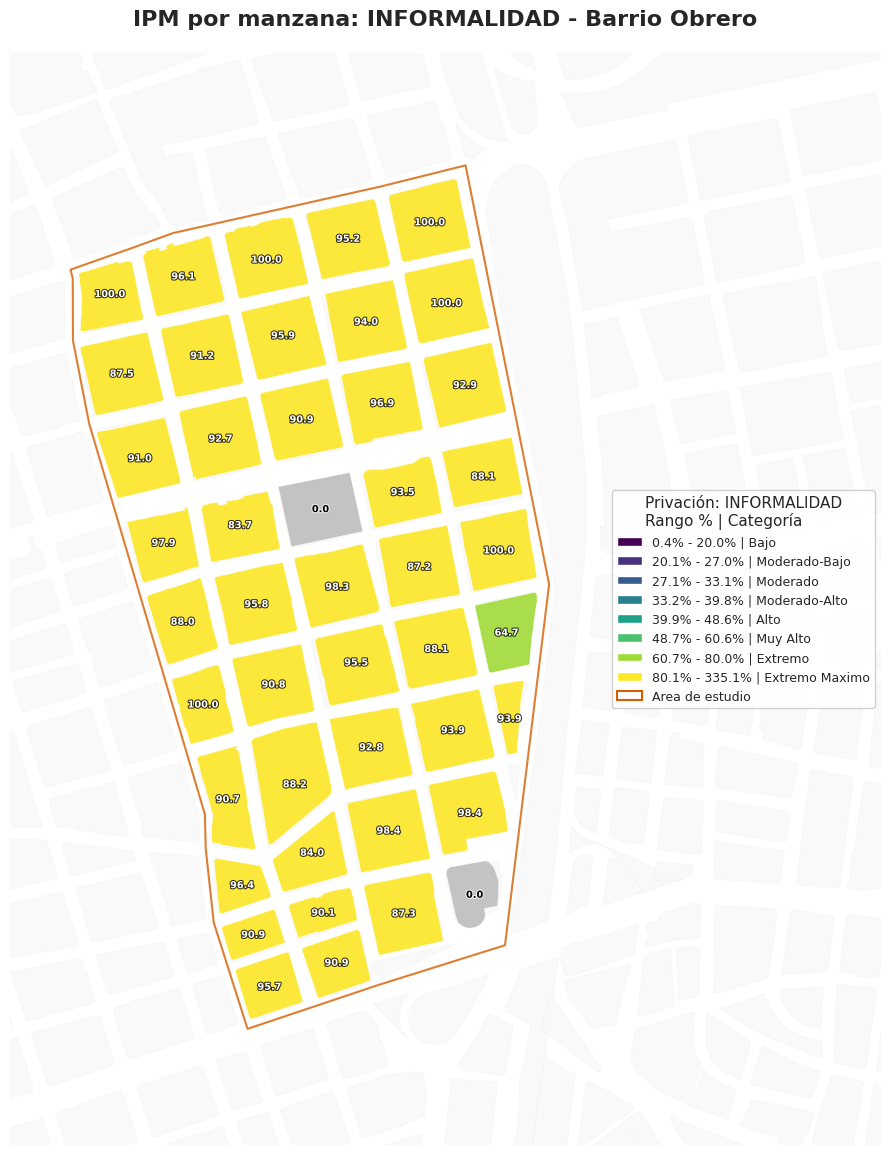

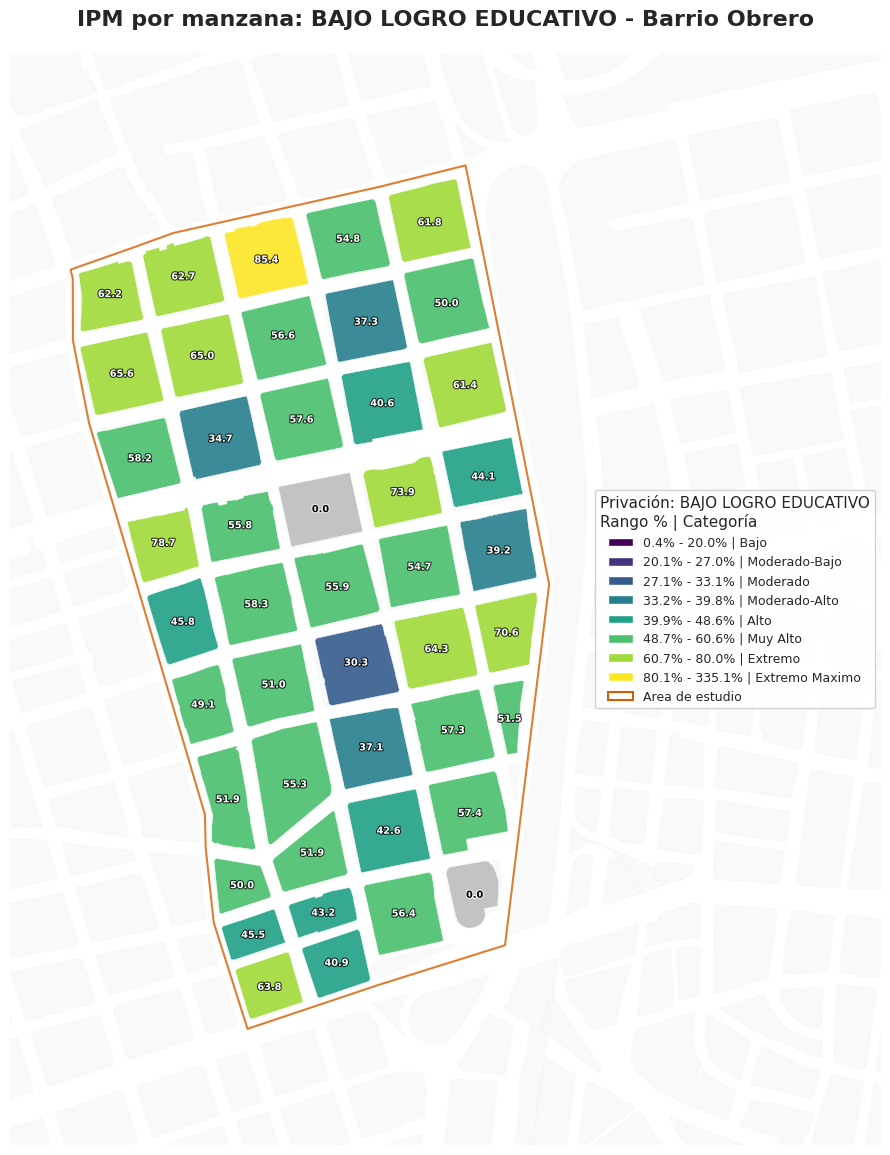

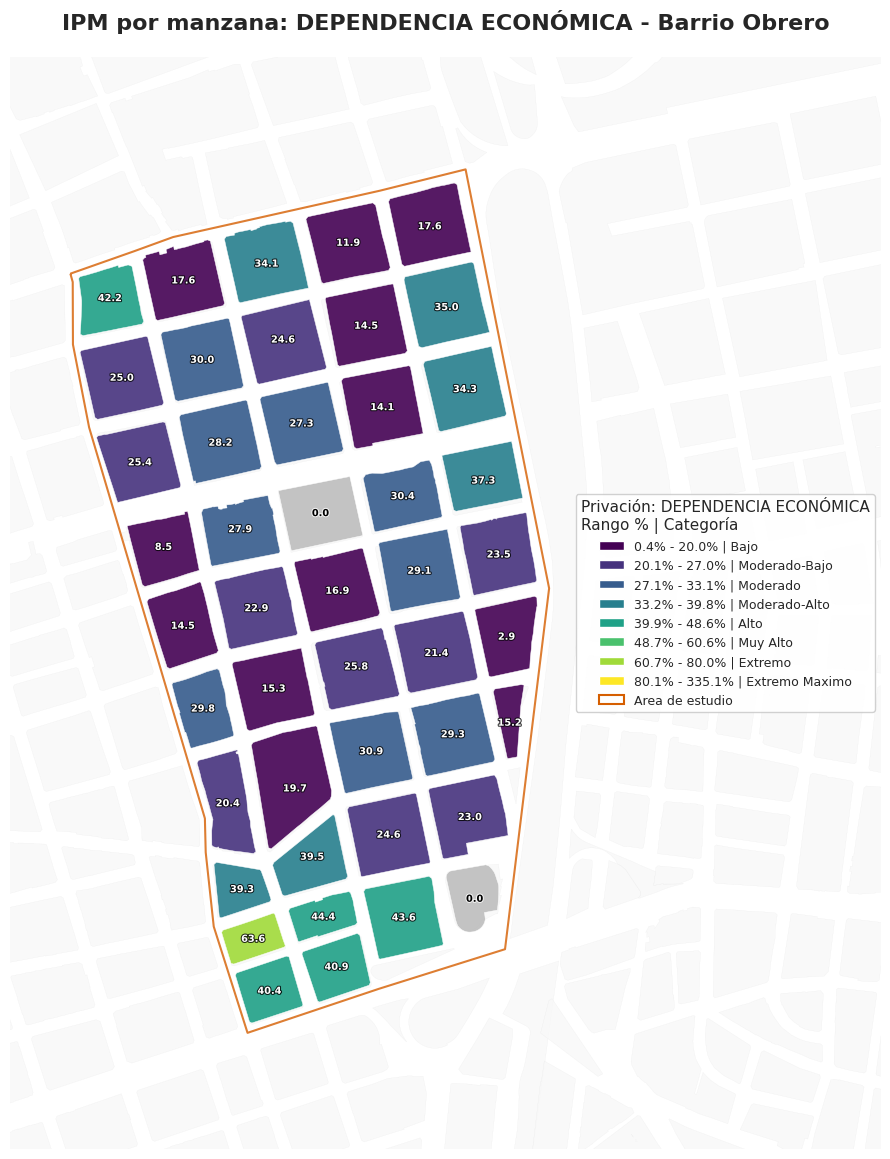

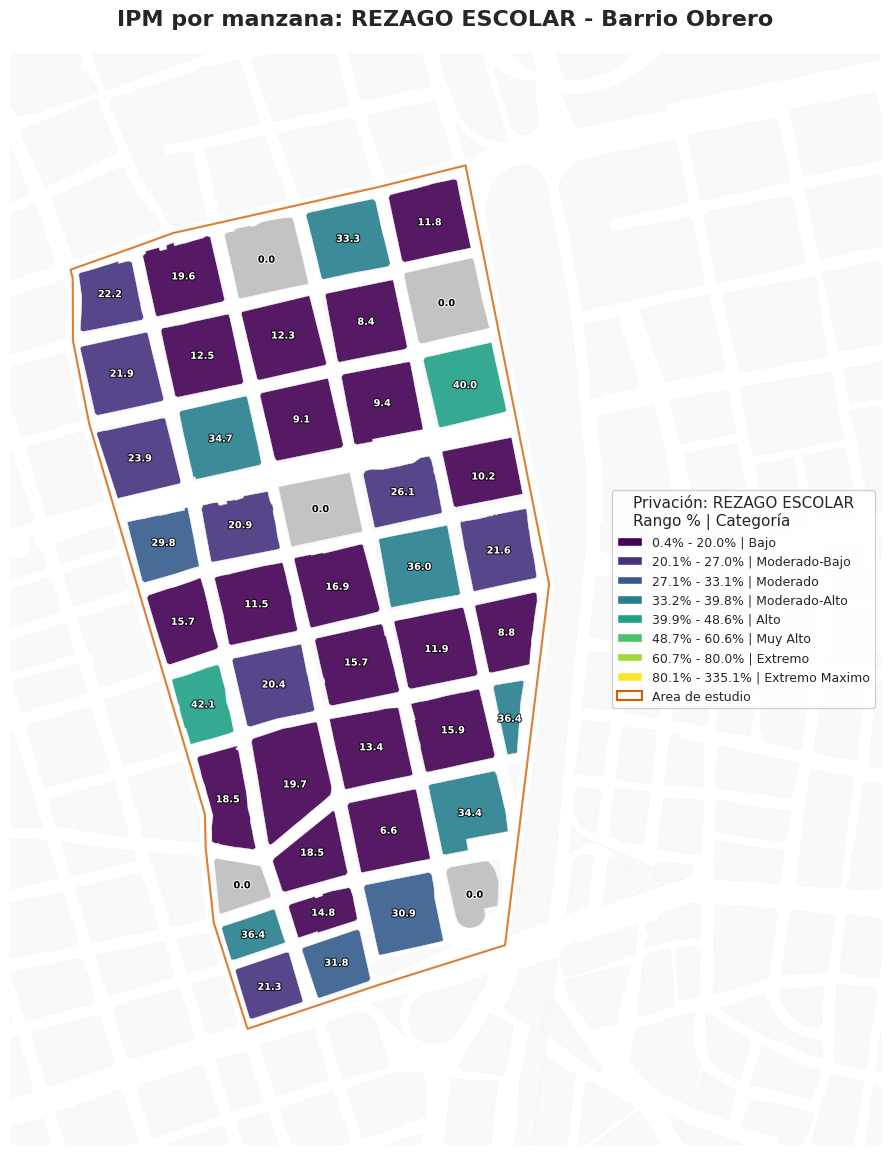

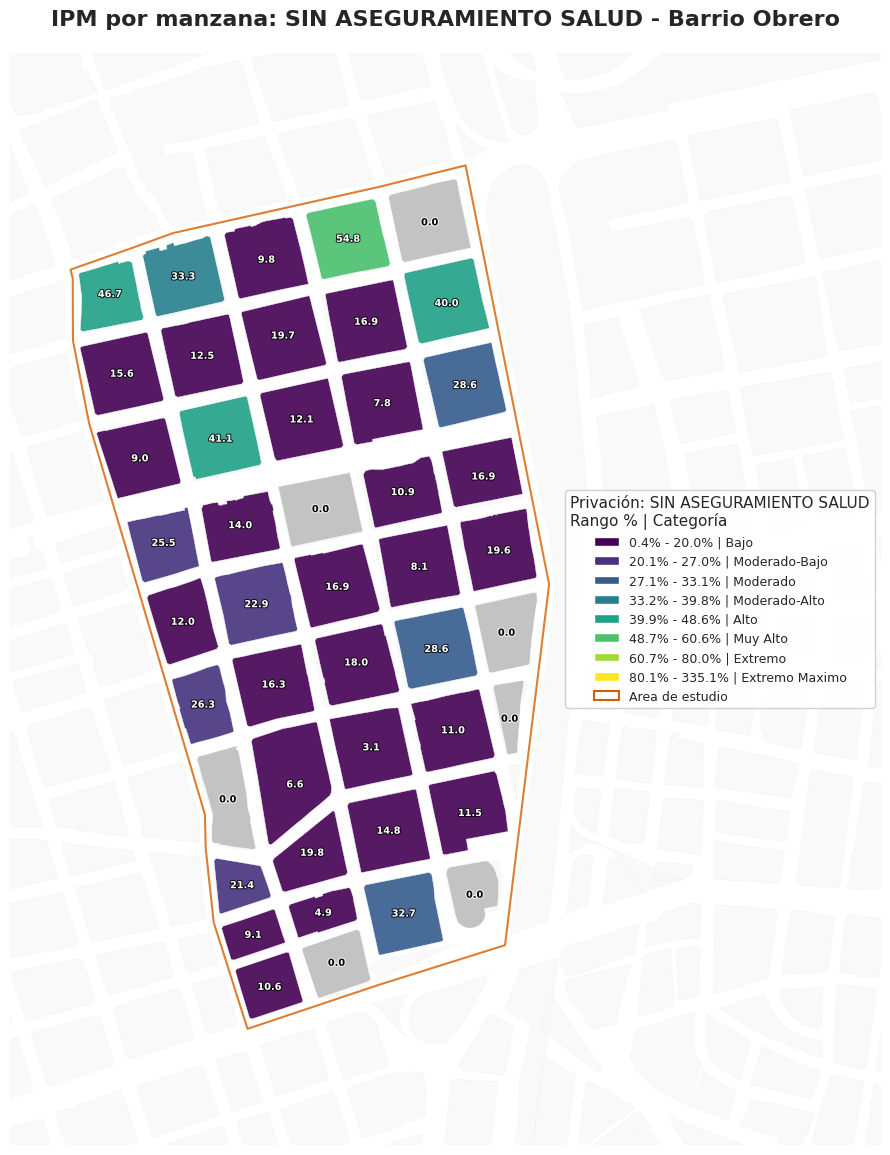

In [6]:
# 6. Generar los 5 mapas prioritarios
print('Generando mapas sincronizados con el Estándar Maestro del Notebook 01...')
for var in top_5:
    plot_ipm_variable_master(gdf, gdf_fondo, gdf_area, var, diccionario_nombres[var])

In [7]:
# 7. Descargar GeoJSON a tu PC (solo funciona en Google Colab)
if 'google.colab' in sys.modules:
    from google.colab import files
    # Exportar las manzanas filtradas de la zona
    output_path = os.path.join(BASE_DIR, 'indice_Pobreza/outputs/IPM_manzanas_Barrio_Obrero.geojson')
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    gdf.to_file(output_path, driver='GeoJSON')
    files.download(output_path)
    print(f'Descarga iniciada: IPM_manzanas_Barrio_Obrero.geojson ({len(gdf)} manzanas)')
else:
    print(f'Archivo fuente: {PATH_IPM_VARS_FULL}')
    print(f'Manzanas en zona: {len(gdf)}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada: IPM_manzanas_Barrio_Obrero.geojson (45 manzanas)
